# Dataset Split Visualizer
Prints per-country pixel counts and plots CISI map overlaid with train/val/test split.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
import rasterio.transform
import geopandas as gpd

In [ ]:
VAL_COUNTRIES  = ["Portugal", "Greece", "Belgium", "Netherlands"]
TEST_COUNTRIES = ["Italy"]

cisi_path = r"READY_data\labels\2024_CISI_010deg_nearest.tif"
shp_path  = r"ne_10m_admin_0_countries\ne_10m_admin_0_countries.shp"

In [13]:
# Load CISI raster
with rasterio.open(cisi_path) as src:
    cisi      = src.read(1).astype(np.float32)
    transform = src.transform
    bounds    = src.bounds

valid_mask    = ~np.isnan(cisi)
valid_indices = np.argwhere(valid_mask)

# Load countries
world = gpd.read_file(shp_path)[['NAME', 'geometry']]

# Pixel -> lon/lat -> country
rows, cols = valid_indices[:, 0], valid_indices[:, 1]
xs, ys     = rasterio.transform.xy(transform, rows, cols)

points = gpd.GeoDataFrame(
    {'pixel_idx': np.arange(len(rows))},
    geometry=gpd.points_from_xy(xs, ys),
    crs='EPSG:4326'
)

print('Running spatial join (may take ~10-30 seconds)...')
joined        = gpd.sjoin(points, world, how='left', predicate='within')
country_names = joined['NAME'].fillna('UNASSIGNED').values
print('Done.')

Running spatial join (may take ~10-30 seconds)...
Done.


In [14]:
# Per-country pixel counts (sorted descending)
unique, counts = np.unique(country_names, return_counts=True)
order          = np.argsort(-counts)

print(f"{'Country':<30} {'Pixels':>8}  Split")
print('-' * 50)
for name, count in zip(unique[order], counts[order]):
    if name in VAL_COUNTRIES:
        split = 'VAL'
    elif name in TEST_COUNTRIES:
        split = 'TEST'
    elif name == 'UNASSIGNED':
        split = '-> train'
    else:
        split = 'train'
    print(f'{name:<30} {count:>8,}  {split}')

val_total   = counts[np.isin(unique, VAL_COUNTRIES)].sum()
test_total  = counts[np.isin(unique, TEST_COUNTRIES)].sum()
train_total = len(valid_indices) - val_total - test_total
print(f'\nTrain: {train_total:,}  |  Val: {val_total:,}  |  Test: {test_total:,}')

Country                          Pixels  Split
--------------------------------------------------
Norway                            8,439  train
Sweden                            7,862  VAL
France                            6,425  train
Finland                           6,231  train
UNASSIGNED                        6,015  -> train
Spain                             5,295  train
Germany                           4,584  train
Russia                            4,138  train
Poland                            4,094  train
Ukraine                           3,792  train
United Kingdom                    3,327  train
Italy                             3,316  TEST
Belarus                           2,779  train
Romania                           2,735  train
Iceland                           1,938  train
Greece                            1,356  VAL
Bulgaria                          1,235  train
Hungary                           1,108  train
Austria                           1,007  train
Czechia    

In [15]:
# Split CISI statistics
val_mask   = np.isin(country_names, VAL_COUNTRIES)
test_mask  = np.isin(country_names, TEST_COUNTRIES)
train_mask = ~val_mask & ~test_mask

cisi_values = cisi[valid_indices[:, 0], valid_indices[:, 1]]

italy_cisi = cisi_values[test_mask]
print(f'Italy total pixels:       {len(italy_cisi):,}')
print(f'Italy high-CISI (>0.15):  {(italy_cisi > 0.15).sum():,}')
print(f'Italy high-CISI (>0.20):  {(italy_cisi > 0.20).sum():,}')
print(f'Italy max CISI:           {italy_cisi.max():.3f}')
print(f'Italy mean CISI:          {italy_cisi.mean():.3f}')

val_cisi = cisi_values[val_mask]
print(f"\nVal total pixels:         {len(val_cisi):,}")
print(f"Val high-CISI (>0.15):    {(val_cisi > 0.15).sum():,}")
print(f"Val high-CISI (>0.20):    {(val_cisi > 0.20).sum():,}")
print(f"Val max CISI:             {val_cisi.max():.3f}")
print(f"Val mean CISI:            {val_cisi.mean():.3f}")

train_cisi = cisi_values[train_mask]
print(f"\nTrain total pixels:       {len(train_cisi):,}")
print(f"Train high-CISI (>0.15):  {(train_cisi > 0.15).sum():,}")
print(f"Train high-CISI (>0.20):  {(train_cisi > 0.20).sum():,}")
print(f"Train max CISI:           {train_cisi.max():.3f}")
print(f"Train mean CISI:          {train_cisi.mean():.3f}")

# Candidate countries to inspect (for adjusting split)
# Note: use shapefile names — "Czechia" not "Czech Republic"
candidates = ["Czechia", "Belgium", "Netherlands",
              "Austria", "Denmark", "Romania", "Hungary"]

print(f"\n{'Country':<22} {'Pixels':>7}  {'High-CISI(>0.15)':>16}  {'%':>5}")
print("-" * 55)
for country in candidates:
    mask = country_names == country
    n = mask.sum()
    n_high = int(((cisi_values > 0.15) & mask).sum())
    pct = 100 * n_high / n if n > 0 else 0
    print(f"{country:<22} {n:>7,}  {n_high:>16,}  {pct:>4.1f}%")

Italy total pixels:       3,316
Italy high-CISI (>0.15):  157
Italy high-CISI (>0.20):  61
Italy max CISI:           0.630
Italy mean CISI:          0.052

Val total pixels:         11,142
Val high-CISI (>0.15):    128
Val high-CISI (>0.20):    45
Val max CISI:             0.552
Val mean CISI:            0.019

Train total pixels:       72,888
Train high-CISI (>0.15):  1,262
Train high-CISI (>0.20):  579
Train max CISI:           0.896
Train mean CISI:          0.029

Country                 Pixels  High-CISI(>0.15)      %
-------------------------------------------------------
Czechia                    987                83   8.4%
Belgium                    395                21   5.3%
Netherlands                486                36   7.4%
Austria                  1,007                51   5.1%
Denmark                    606                 3   0.5%
Romania                  2,735                21   0.8%
Hungary                  1,108                34   3.1%


Saved split_map.png


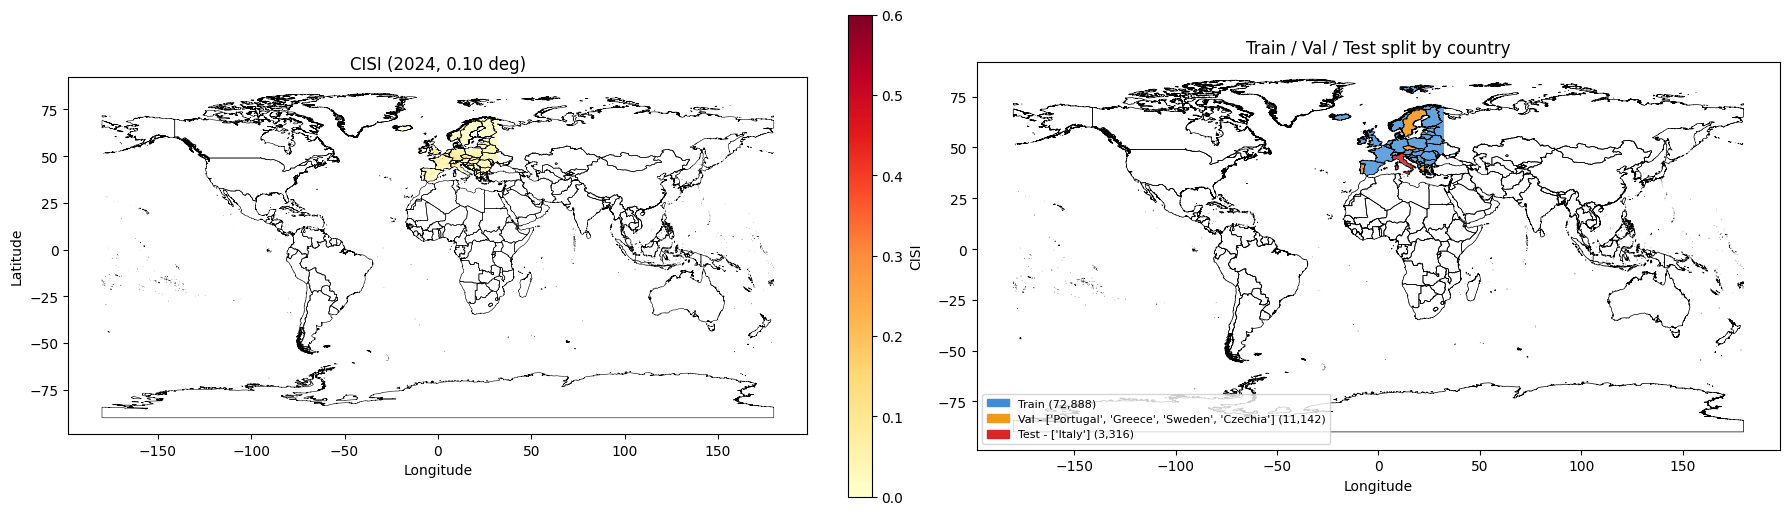

In [16]:
# Build split mask raster (0=outside, 1=train, 2=val, 3=test)
split_raster = np.zeros(cisi.shape, dtype=np.uint8)
for pixel_idx, country in enumerate(country_names):
    r, c = valid_indices[pixel_idx]
    if country in VAL_COUNTRIES:
        split_raster[r, c] = 2
    elif country in TEST_COUNTRIES:
        split_raster[r, c] = 3
    else:
        split_raster[r, c] = 1

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: CISI map
ax = axes[0]
cisi_plot = np.where(valid_mask, cisi, np.nan)
im = ax.imshow(cisi_plot, cmap='YlOrRd', vmin=0, vmax=0.6,
               extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
               origin='upper', aspect='auto')
world.boundary.plot(ax=ax, linewidth=0.4, color='black')
plt.colorbar(im, ax=ax, label='CISI', fraction=0.03)
ax.set_title('CISI (2024, 0.10 deg)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

# Right: Split map
ax = axes[1]
colors = np.zeros((*cisi.shape, 4), dtype=np.float32)
colors[split_raster == 1] = [0.25, 0.55, 0.85, 0.8]  # train - blue
colors[split_raster == 2] = [0.95, 0.60, 0.10, 0.9]  # val   - orange
colors[split_raster == 3] = [0.85, 0.15, 0.15, 0.9]  # test  - red

ax.imshow(colors,
          extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
          origin='upper', aspect='auto')
world.boundary.plot(ax=ax, linewidth=0.5, color='black')

patches = [
    mpatches.Patch(color=[0.25, 0.55, 0.85], label=f'Train ({train_total:,})'),
    mpatches.Patch(color=[0.95, 0.60, 0.10], label=f'Val - {VAL_COUNTRIES} ({val_total:,})'),
    mpatches.Patch(color=[0.85, 0.15, 0.15], label=f'Test - {TEST_COUNTRIES} ({test_total:,})'),
]
ax.legend(handles=patches, loc='lower left', fontsize=8)
ax.set_title('Train / Val / Test split by country')
ax.set_xlabel('Longitude')

plt.tight_layout()
plt.savefig('split_map.png', dpi=150, bbox_inches='tight')
print('Saved split_map.png')
plt.show()